# Post 10: What Does Umbrella Sampling Actually Sample?

This notebook is the presentation layer for the tenth tutorial. The reusable umbrella sampling, WHAM-style reconstruction, overlap diagnostics, and figure logic lives in `src/kups_md_tutorials/`.

In [1]:
from pathlib import Path
import json
import os

from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "configs").exists():
    repo_root = repo_root.parent
os.chdir(repo_root)
repo_root

PosixPath('/home/sungs/kups-md-tutorials')

In [2]:
from kups_md_tutorials.umbrella_sampling import load_umbrella_summary
from kups_md_tutorials.figures import generate_post10_figures

## Configuration

The smoke and full profiles compare dense and sparse harmonic umbrella windows on the same double-well PMF. The comparison isolates window placement, adjacent overlap, and reconstruction consistency.

In [3]:
for path in [Path("configs/post-10/smoke.json"), Path("configs/post-10/full.json")]:
    config = json.loads(path.read_text())
    print(path)
    print(json.dumps(config["umbrella_experiment"], indent=2))

configs/post-10/smoke.json
{
  "temperature": 1.0,
  "domain_min": -2.5,
  "domain_max": 2.5,
  "grid_points": 1201,
  "bin_width": 0.08,
  "sample_count_per_window": 2500,
  "seed": 2026071410,
  "protocols": [
    {
      "name": "dense_windows",
      "force_constant": 18.0,
      "window_centers": [
        -1.6,
        -1.2,
        -0.8,
        -0.4,
        0.0,
        0.4,
        0.8,
        1.2,
        1.6
      ]
    },
    {
      "name": "sparse_windows",
      "force_constant": 18.0,
      "window_centers": [
        -1.6,
        -0.8,
        0.8,
        1.6
      ]
    }
  ]
}
configs/post-10/full.json
{
  "temperature": 1.0,
  "domain_min": -2.5,
  "domain_max": 2.5,
  "grid_points": 2001,
  "bin_width": 0.04,
  "sample_count_per_window": 20000,
  "seed": 2026071410,
  "protocols": [
    {
      "name": "dense_windows",
      "force_constant": 18.0,
      "window_centers": [
        -1.6,
        -1.2,
        -0.8,
        -0.4,
        0.0,
        0.4,
      

## Committed Full-Profile Diagnostics

The summary records reconstructed barrier error, PMF RMSE, adjacent overlap, replica consistency, local replica disagreement, and per-window sampling support.


In [4]:
summary = load_umbrella_summary(Path("results/post-10/full/umbrella_summary.json"))
for protocol in summary.protocols:
    print(protocol.protocol)
    print(f"  windows: {protocol.window_count}")
    print(f"  barrier error: {protocol.barrier_error:.4f}")
    print(f"  PMF RMSE: {protocol.pmf_rmse_vs_true:.4f}")
    print(f"  min adjacent overlap: {protocol.min_adjacent_overlap:.4f}")
    print(f"  replica PMF RMSE: {protocol.forward_reverse_pmf_rmse:.4f}")
    print(f"  max local replica difference: {protocol.max_replica_pmf_difference:.4f}")
    print(f"  barrier replica difference: {protocol.barrier_replica_difference:.4f}")

if summary.pair_distance_umbrella is not None:
    pair = summary.pair_distance_umbrella
    print("pair_distance_umbrella")
    print(f"  windows: {pair.window_count}")
    print(f"  coordinate: {pair.coordinate}")
    print(f"  minimum radius: {pair.minimum_radius:.4f}")
    print(f"  well-depth error: {pair.well_depth_error:.4f}")
    print(f"  PMF RMSE: {pair.pmf_rmse_vs_true:.4f}")
    print(f"  min adjacent overlap: {pair.min_adjacent_overlap:.4f}")
    print(f"  replica PMF RMSE: {pair.forward_reverse_pmf_rmse:.4f}")
    print(f"  target device: {pair.target_device}")
    print(f"  runtime device: {pair.runtime_device}")
    print(f"  production GPU ready: {pair.production_gpu_ready}")
    print(f"  GPU blocking reason: {pair.gpu_blocking_reason}")


dense_windows
  windows: 9
  barrier error: 0.0106
  PMF RMSE: 0.1730
  min adjacent overlap: 0.3552
  replica PMF RMSE: 0.1148
  max local replica difference: 0.6938
  barrier replica difference: 0.0206
sparse_windows
  windows: 4
  barrier error: -0.2554
  PMF RMSE: 0.2229
  min adjacent overlap: 0.0003
  replica PMF RMSE: 0.2352
  max local replica difference: 0.9656
  barrier replica difference: 0.0151
pair_distance_umbrella
  windows: 8
  coordinate: reduced pair distance r/sigma
  minimum radius: 1.1325
  well-depth error: 0.0053
  PMF RMSE: 0.1380
  min adjacent overlap: 0.3109
  replica PMF RMSE: 0.0924
  target device: cuda_or_cpu_fallback
  runtime device: jax:cpu;devices:cpu
  production GPU ready: False
  GPU blocking reason: target device requests CUDA/GPU, but generated artifact runtime was jax:cpu;devices:cpu


## Figure Regeneration

The figure is regenerated from committed compact output files, not from notebook-local simulation code.

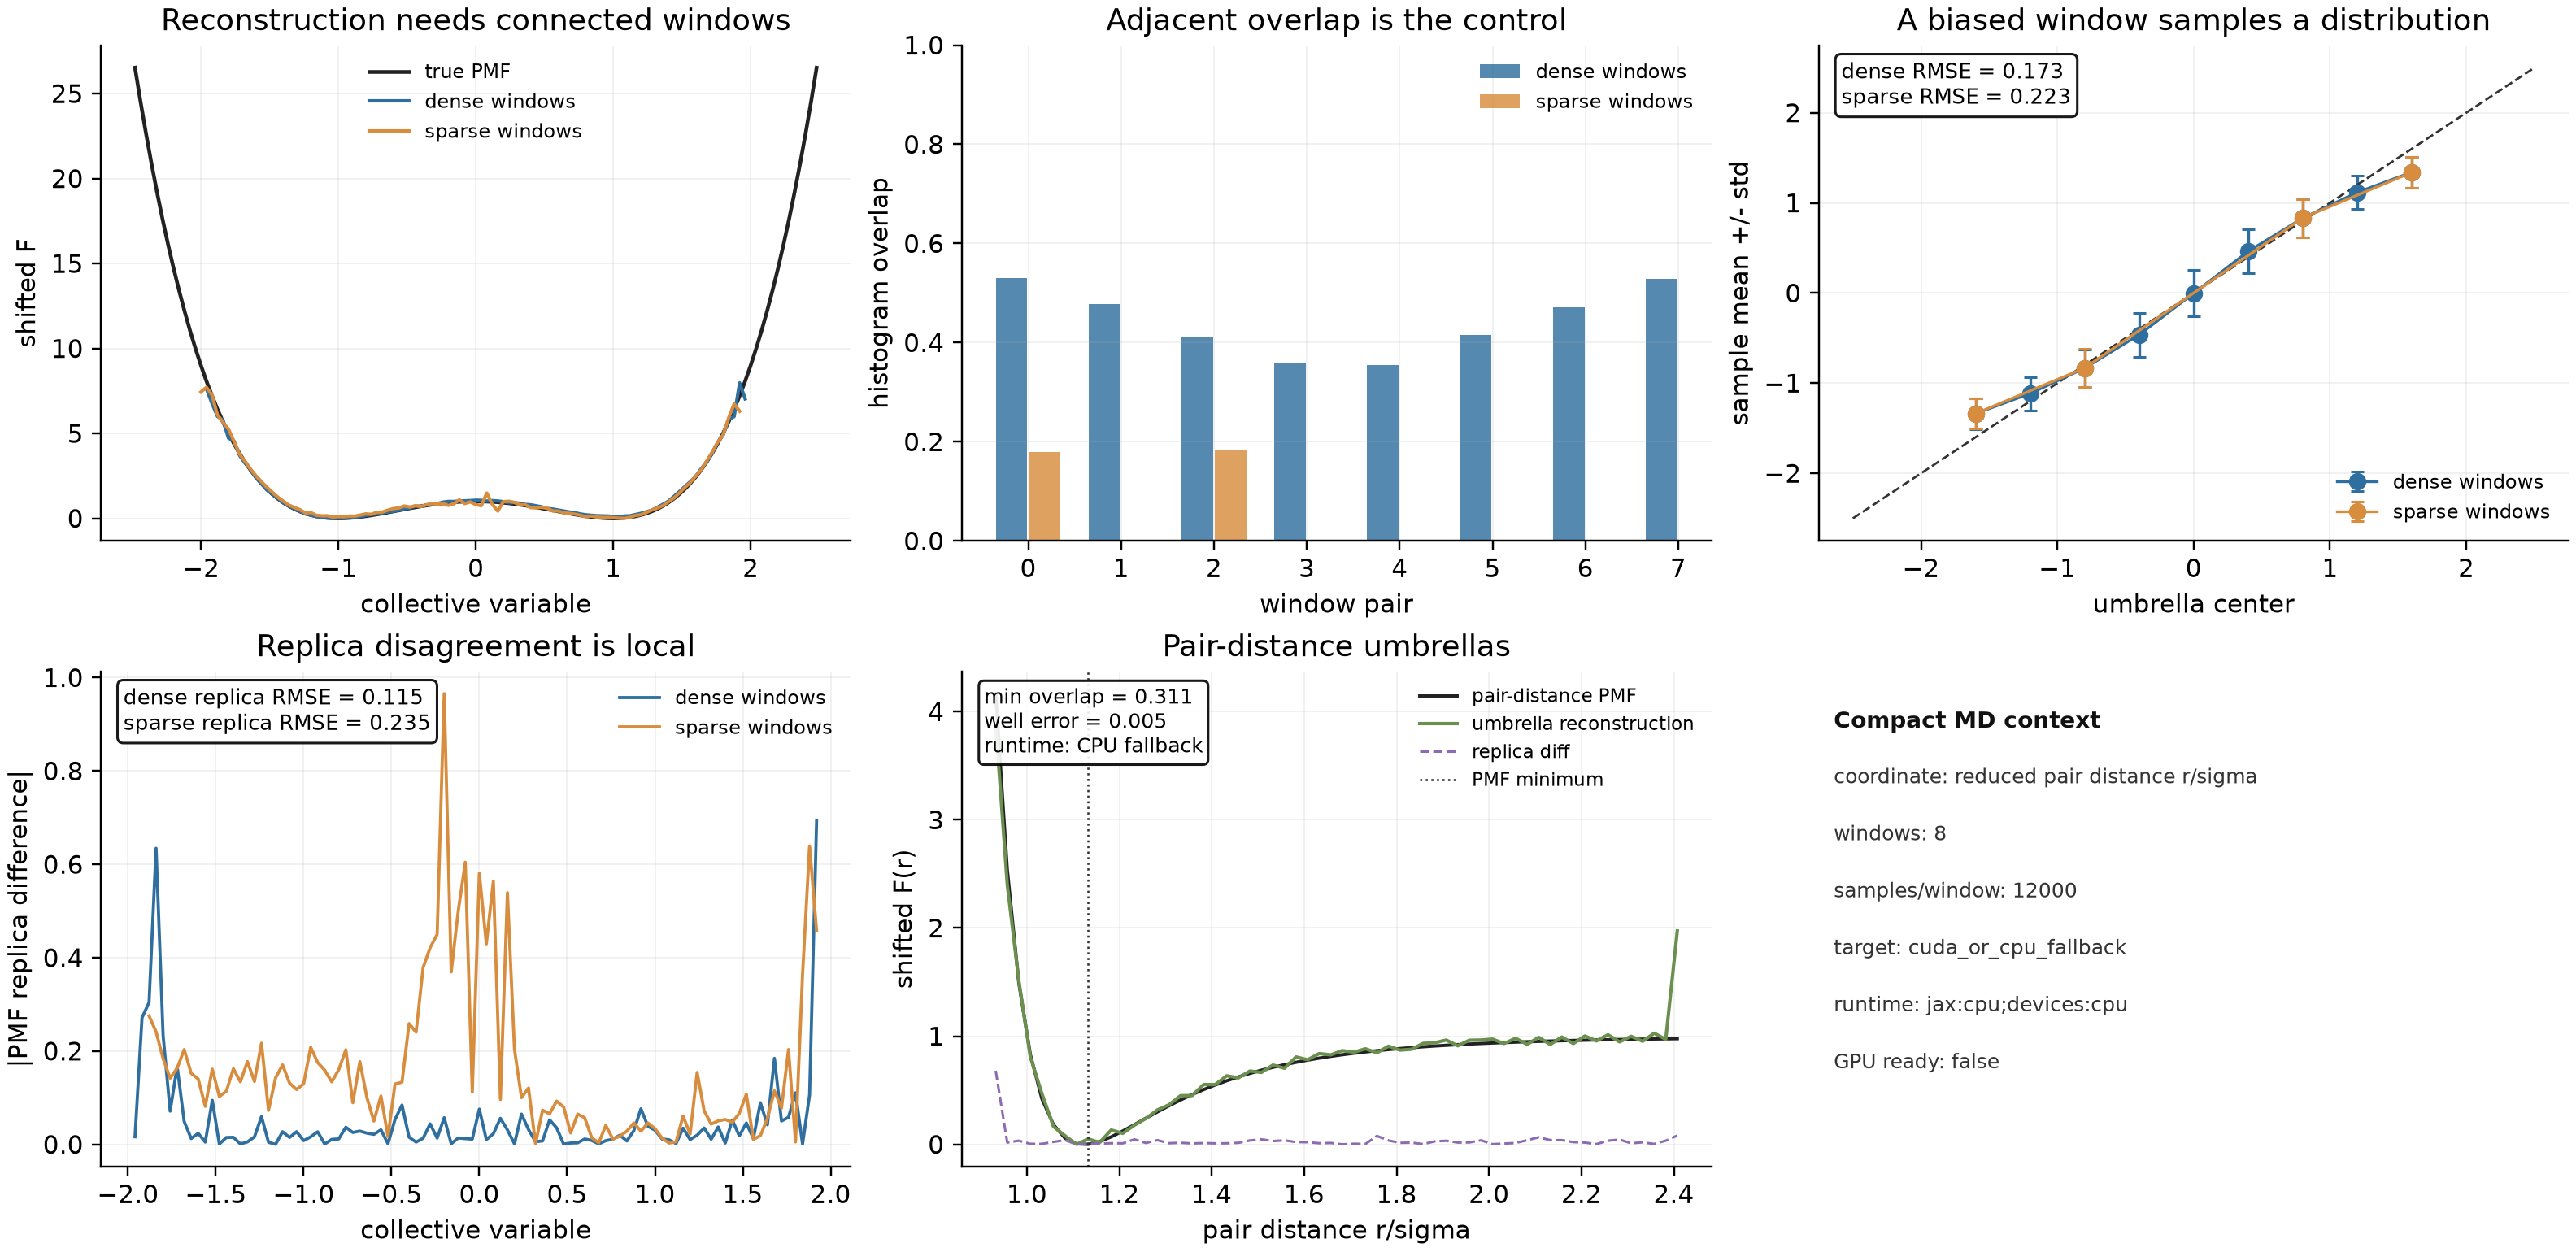

In [5]:
generate_post10_figures(
    result_dir=Path("results/post-10/full"),
    figure_dir=Path("figures/post-10"),
    snapshot_dir=Path("snapshots/post-10"),
    name="umbrella_diagnostics_full",
)
display(Image(filename="figures/post-10/umbrella_diagnostics_full.png"))